# 🫀 Heart Disease  —  Machine Learning 

> **Objectif** : Développer un modèle de classification binaire capable de prédire la présence ou l'absence de maladie cardiaque à partir de données cliniques.

---

## 📌 Étape 1 : Imports & Chargement des Données

In [ ]:
# ── Bibliothèques standard ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Machine Learning ────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)

# ── Statistiques ────────────────────────────────────────────────────────────
import statsmodels.api as sm

# ── Paramètres d'affichage ──────────────────────────────────────────────────
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

print('Bibliothèques importées avec succès')

✅ Bibliothèques importées avec succès


In [ ]:
# ── Chargement du dataset ───────────────────────────────────────────────────
df = pd.read_csv('heart_disease_uci.csv')

print('=' * 55)
print(f'   Dimensions         : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print('=' * 55)
print(f'  Mémoire               : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print('=' * 55)
df.head()

  📊 Dimensions         : 920 lignes × 16 colonnes
  Mémoire               : 413.6 KB


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.000,233.000,True,lv hypertrophy,150.000,False,2.300,downsloping,0.000,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.000,286.000,False,lv hypertrophy,108.000,True,1.500,flat,3.000,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.000,229.000,False,lv hypertrophy,129.000,True,2.600,flat,2.000,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.000,250.000,False,normal,187.000,False,3.500,downsloping,0.000,normal,0
4,5,41,Female,Cleveland,atypical angina,130.000,204.000,False,lv hypertrophy,172.000,False,1.400,upsloping,0.000,normal,0


In [36]:
# ── Types et aperçu général ─────────────────────────────────────────────────
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


---
## 📌 Étape 2 : Analyse Exploratoire des Données (EDA)

### 2.1 Statistiques Descriptives

In [37]:
print('─── Variables NUMÉRIQUES ───')
display(df.describe().T.style.background_gradient(cmap='Blues', axis=1))

─── Variables NUMÉRIQUES ───


,count,mean,std,min,25%,50%,75%,max
id,920.000000,460.500000,265.725422,1.000000,230.750000,460.500000,690.250000,920.000000
age,920.000000,53.510870,9.424685,28.000000,47.000000,54.000000,60.000000,77.000000
trestbps,861.000000,132.132404,19.066070,0.000000,120.000000,130.000000,140.000000,200.000000
chol,890.000000,199.130337,110.780810,0.000000,175.000000,223.000000,268.000000,603.000000
thalch,865.000000,137.545665,25.926276,60.000000,120.000000,140.000000,157.000000,202.000000
oldpeak,858.000000,0.878788,1.091226,-2.600000,0.000000,0.500000,1.500000,6.200000
ca,309.000000,0.676375,0.935653,0.000000,0.000000,0.000000,1.000000,3.000000
num,920.000000,0.995652,1.142693,0.000000,0.000000,1.000000,2.000000,4.000000


In [38]:
print('─── Variables CATÉGORIELLES ───')
display(df.describe(include='object'))

─── Variables CATÉGORIELLES ───


,sex,dataset,cp,fbs,restecg,exang,slope,thal
count,920,920,920,830,918,865,611,434
unique,2,4,4,2,3,2,3,3
top,Male,Cleveland,asymptomatic,False,normal,False,flat,normal
freq,726,304,496,692,551,528,345,196


### 2.2 Analyse des Valeurs Manquantes

,Manquants,Pourcentage (%)
ca,611,66.4%
thal,486,52.8%
slope,309,33.6%
fbs,90,9.8%
oldpeak,62,6.7%
trestbps,59,6.4%
exang,55,6.0%
thalch,55,6.0%
chol,30,3.3%
restecg,2,0.2%


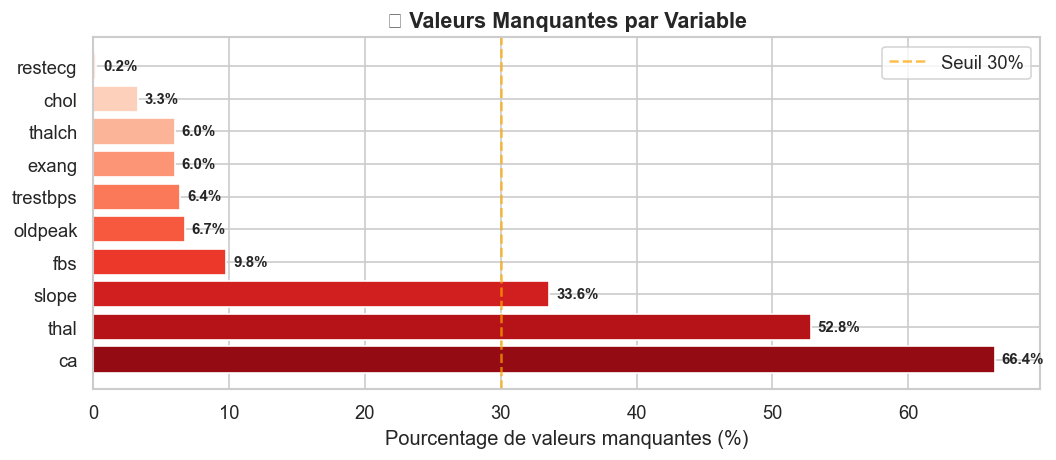

In [39]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Manquants': missing,
    'Pourcentage (%)': missing_pct
}).query('Manquants > 0').sort_values('Pourcentage (%)', ascending=False)

display(missing_df.style.background_gradient(cmap='Reds').format({'Pourcentage (%)': '{:.1f}%'}))

# Visualisation
fig, ax = plt.subplots(figsize=(9, 4))
colors = sns.color_palette('Reds_r', len(missing_df))
bars = ax.barh(missing_df.index, missing_df['Pourcentage (%)'], color=colors, edgecolor='white')
for bar, val in zip(bars, missing_df['Pourcentage (%)']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
ax.axvline(x=30, color='orange', linestyle='--', alpha=0.7, label='Seuil 30%')
ax.set_xlabel('Pourcentage de valeurs manquantes (%)')
ax.set_title('📊 Valeurs Manquantes par Variable', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 2.3 Distribution de la Variable Cible

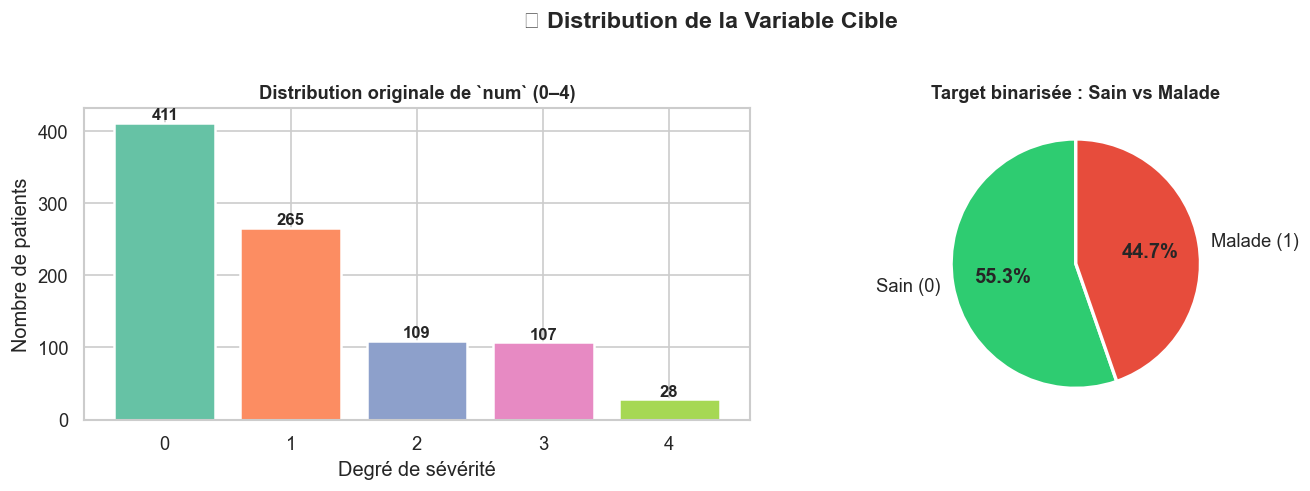


📊 Équilibre des classes :
   Sains   :  411 (44.7%)
   Malades :  509 (55.3%)


In [ ]:
# Créer la variable cible binarisée
df['target'] = (df['num'] > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Countplot distribution originale num (0-4)
palette = sns.color_palette('Set2', 5)
counts = df['num'].value_counts().sort_index()
bars = axes[0].bar(counts.index.astype(str), counts.values, color=palette, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Distribution originale de `num` (0–4)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Degré de sévérité')
axes[0].set_ylabel('Nombre de patients')

# Pie chart variable binarisée
target_counts = df['target'].value_counts()
labels = ['Sain (0)', 'Malade (1)']
colors_pie = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = axes[1].pie(
    target_counts.values, labels=labels, colors=colors_pie,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[1].set_title('Target binarisée : Sain vs Malade', fontsize=11, fontweight='bold')

plt.suptitle(' Distribution de la Variable Cible', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n Équilibre des classes :')
print(f'   Sains   : {target_counts[0]:>4} ({target_counts[0]/len(df)*100:.1f}%)')
print(f'   Malades : {target_counts[1]:>4} ({target_counts[1]/len(df)*100:.1f}%)')

### 2.4 Distributions des Variables Numériques

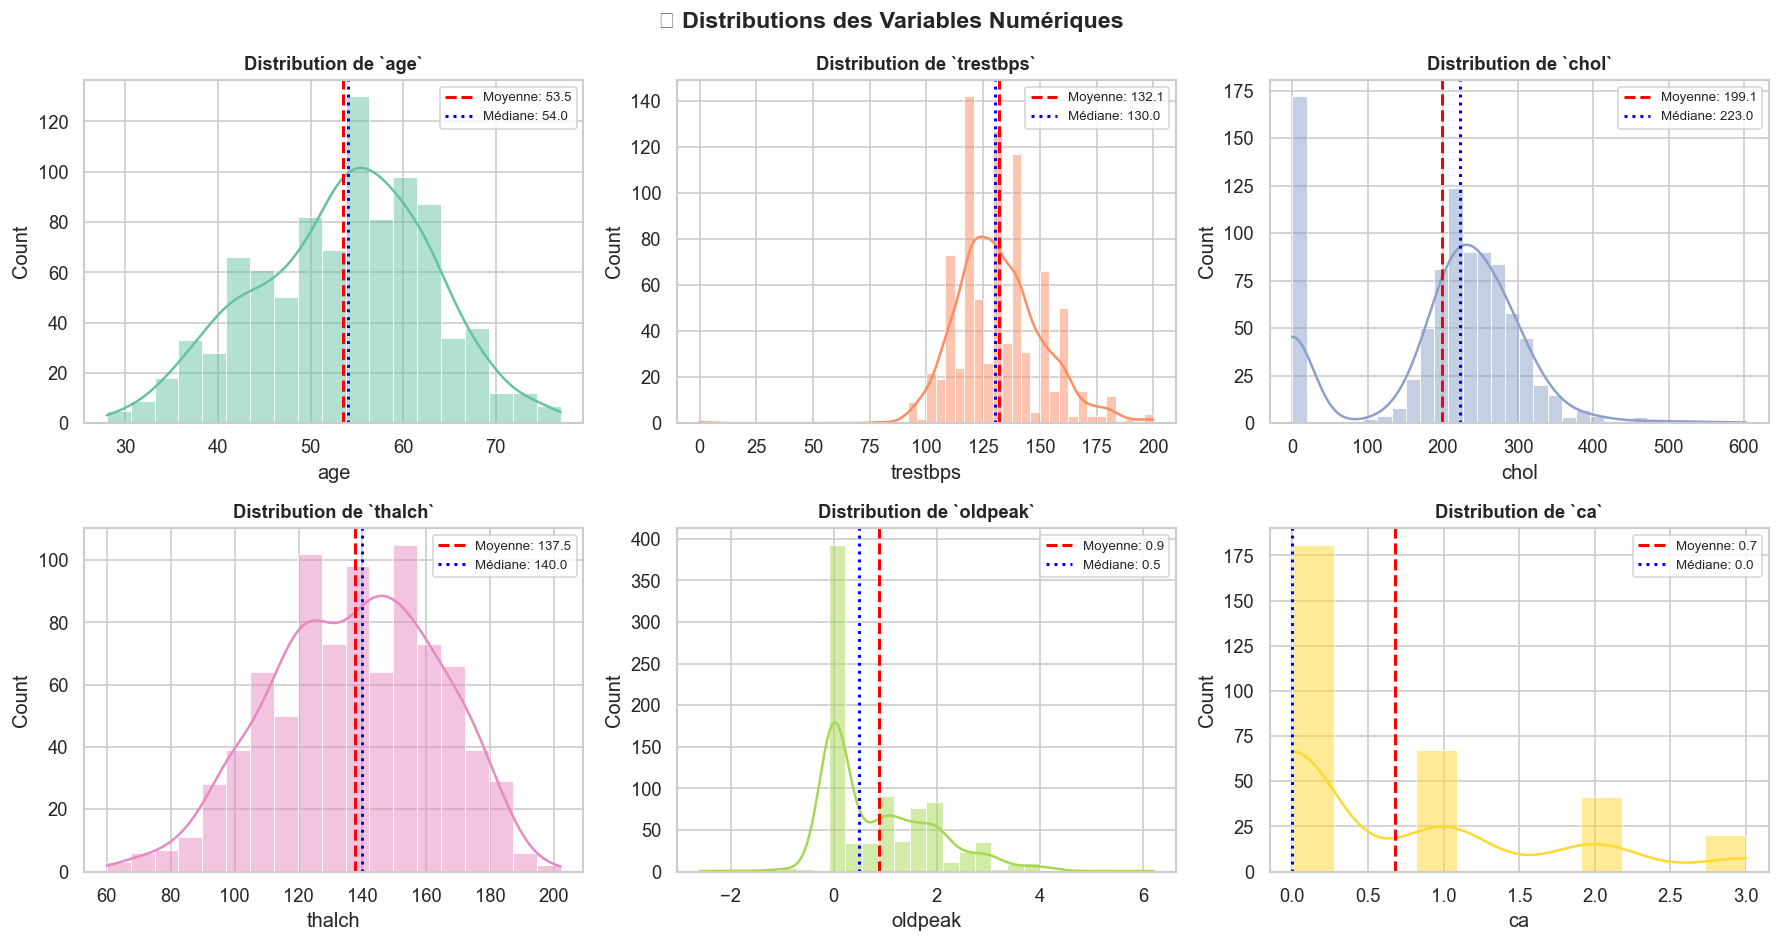

In [41]:
num_vars = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(num_vars):
    data = df[var].dropna()
    sns.histplot(data, kde=True, ax=axes[i], color=sns.color_palette('Set2')[i],
                 edgecolor='white', linewidth=0.5)
    axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=1.8, label=f'Moyenne: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='blue', linestyle=':', linewidth=1.8, label=f'Médiane: {data.median():.1f}')
    axes[i].set_title(f'Distribution de `{var}`', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].legend(fontsize=8)

plt.suptitle('📈 Distributions des Variables Numériques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.5 Détection des Outliers (Boxplots)

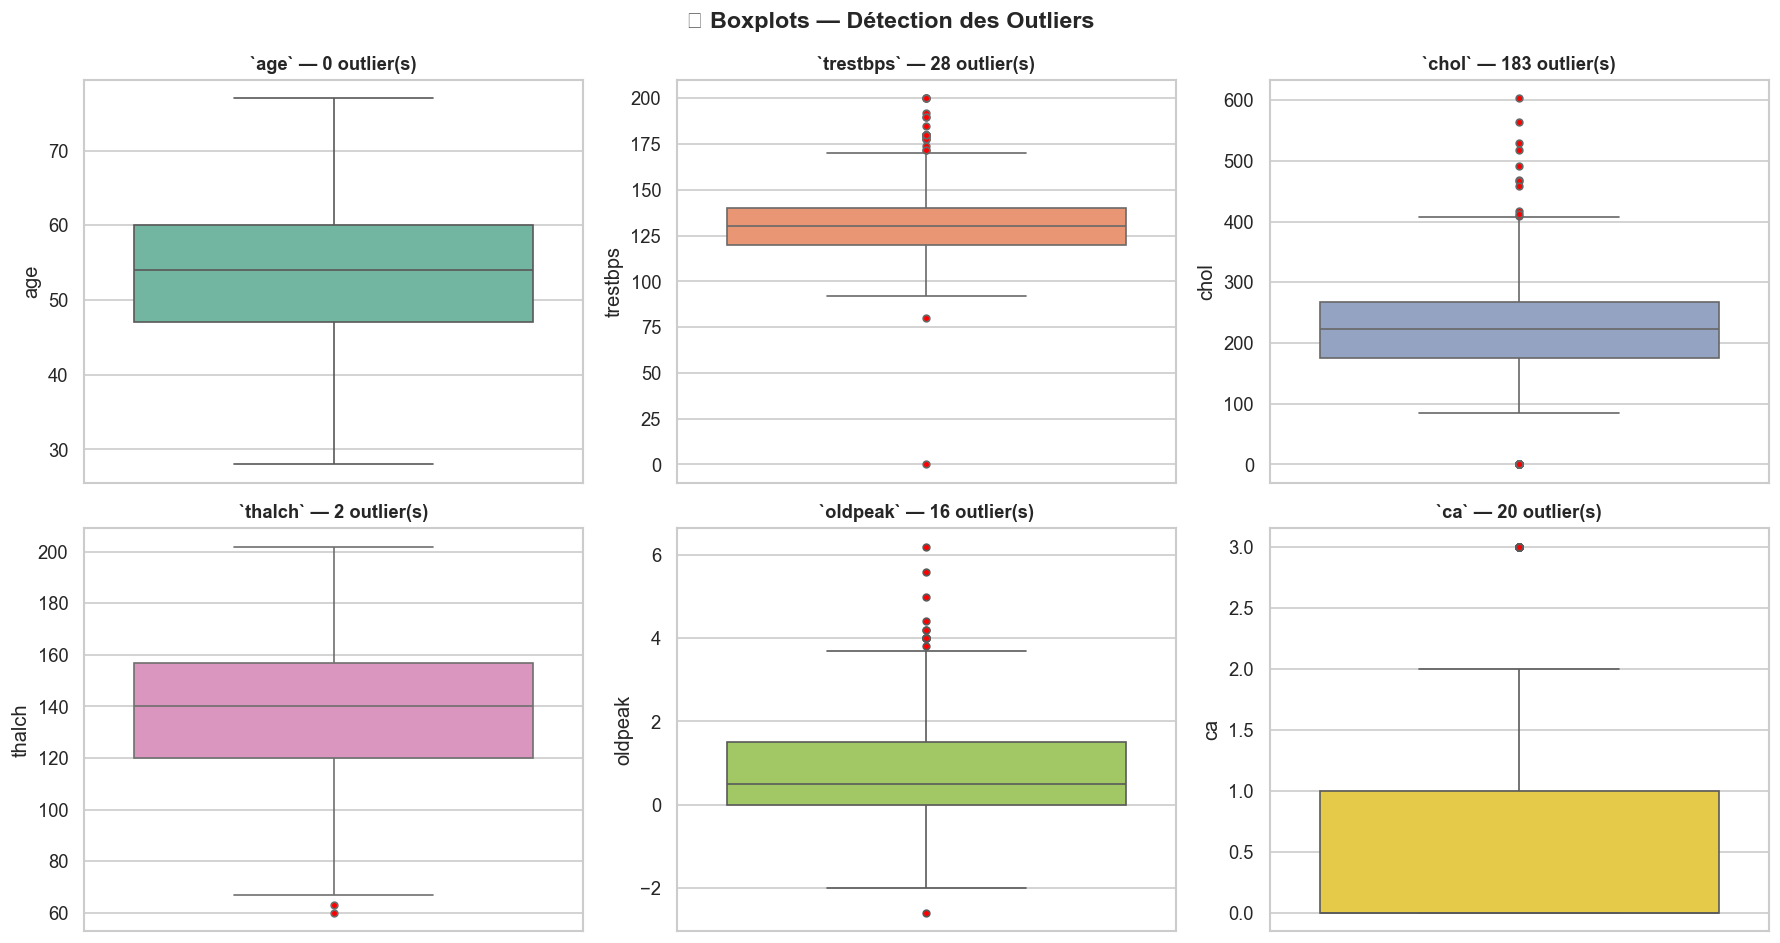

⚠️  chol = 0    : 172 cas
⚠️  trestbps = 0: 1 cas


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(num_vars):
    data = df[var].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
    
    sns.boxplot(y=data, ax=axes[i], color=sns.color_palette('Set2')[i],
                flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 4})
    axes[i].set_title(f'`{var}` — {len(outliers)} outlier(s)', fontsize=11, fontweight='bold')
    axes[i].set_ylabel(var)

plt.suptitle('📦 Boxplots — Détection des Outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Valeurs aberrantes spécifiques
print(f' chol = 0    : {(df["chol"] == 0).sum()} cas')
print(f' trestbps = 0: {(df["trestbps"] == 0).sum()} cas')

### 2.6 Distribution des Variables Catégorielles

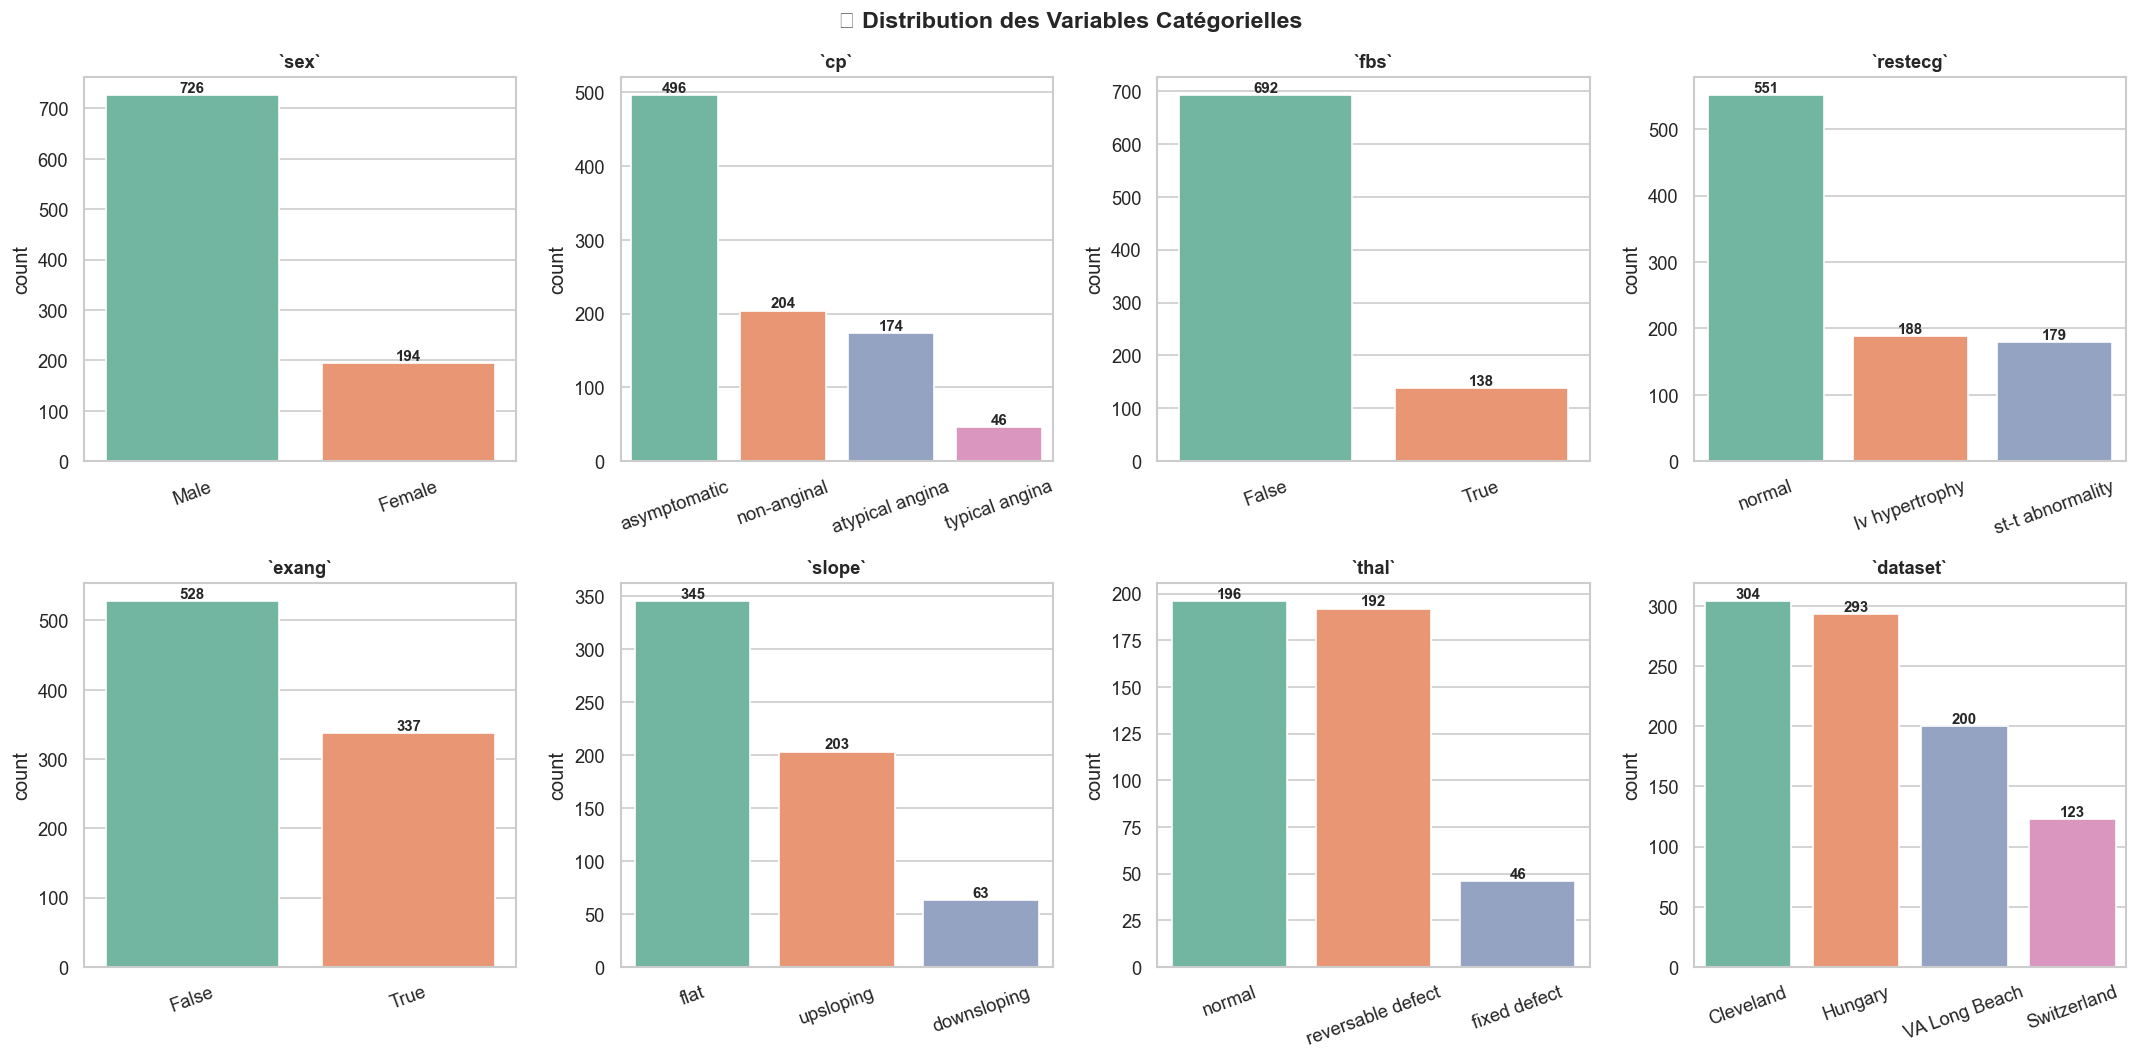

In [ ]:
cat_vars = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'dataset']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    data = df[var].dropna()
    order = data.value_counts().index
    palette = sns.color_palette('Set2', len(order))
    bars = sns.countplot(x=data, ax=axes[i], order=order, palette=palette,
                         edgecolor='white', linewidth=1)
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}',
                         (p.get_x() + p.get_width()/2, p.get_height()),
                         ha='center', va='bottom', fontsize=9, fontweight='bold')
    axes[i].set_title(f'`{var}`', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle(' Distribution des Variables Catégorielles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.7 Matrice de Corrélation

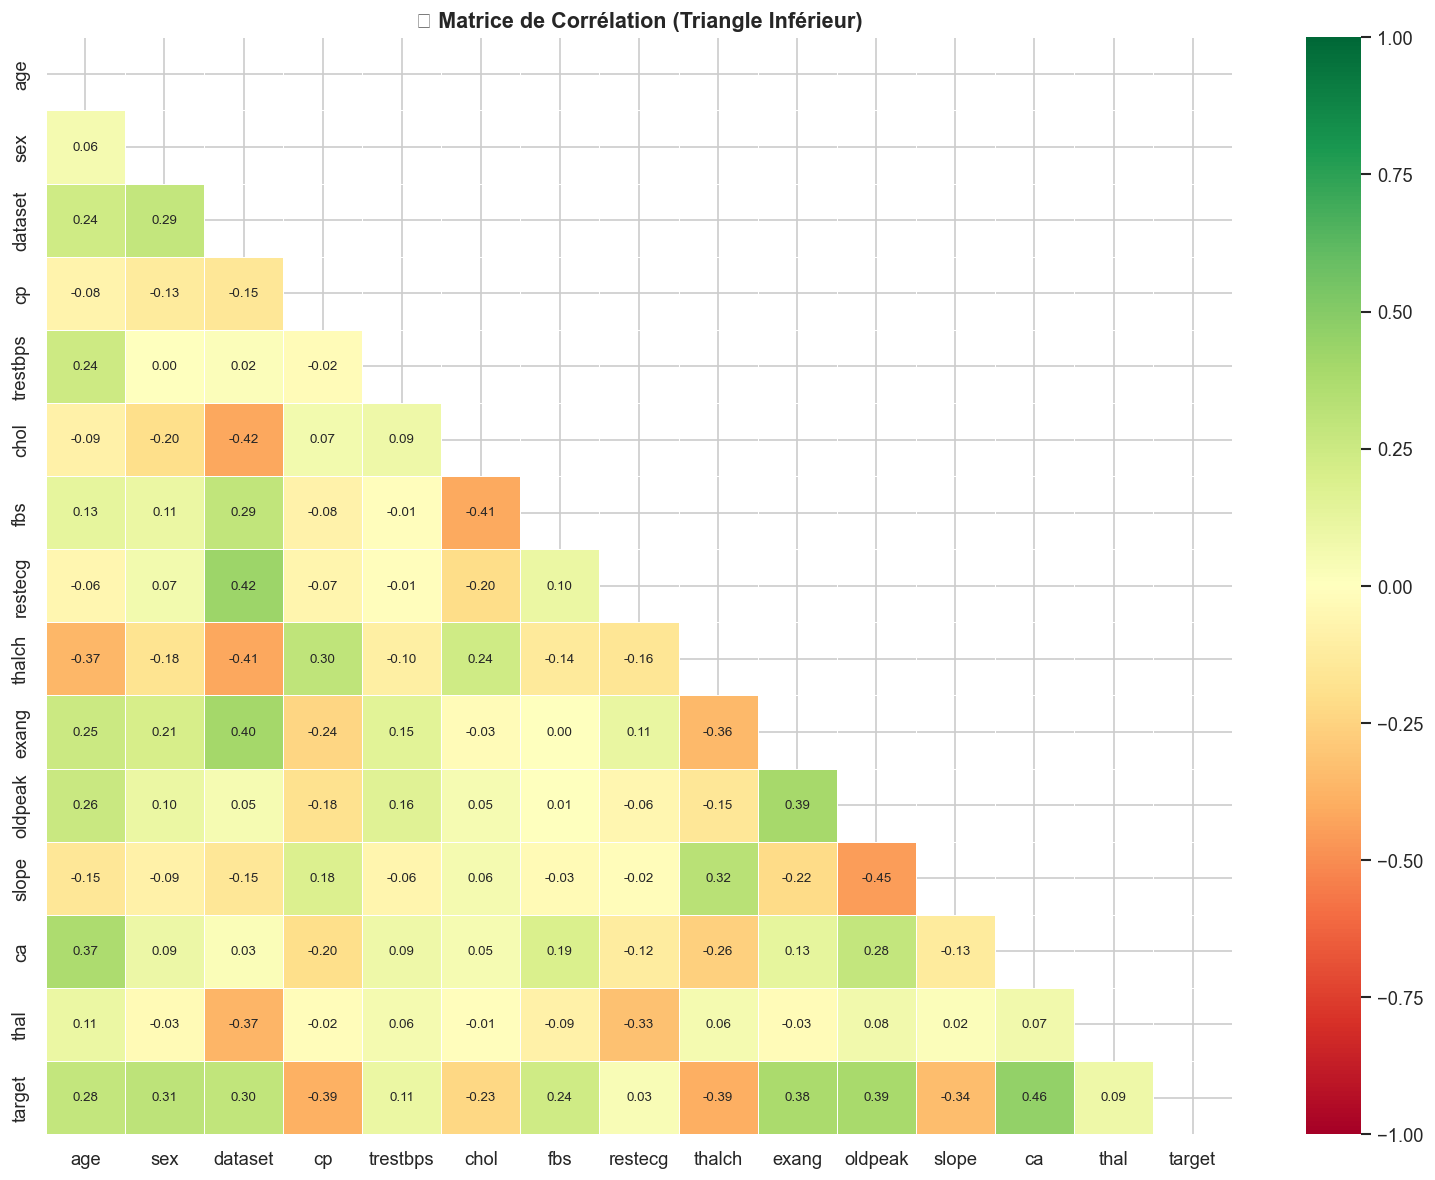


🎯 Top corrélations avec la variable cible (target) :


,|corrélation|
ca,0.455599
thalch,0.394503
oldpeak,0.385528
cp,0.385077
exang,0.376623
slope,0.339925
sex,0.307284
dataset,0.295696
age,0.282700
fbs,0.235853


In [ ]:
# Encodage temporaire pour la corrélation
df_corr = df.copy()
le_temp = LabelEncoder()
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = le_temp.fit_transform(df_corr[col].astype(str))
df_corr = df_corr.drop(columns=['id', 'num'], errors='ignore')

corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8}, linewidths=0.5, linecolor='white')
ax.set_title('🔗 Matrice de Corrélation (Triangle Inférieur)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Top corrélations avec target
print('\n Top corrélations avec la variable cible (target) :')
target_corr = corr_matrix['target'].drop('target').abs().sort_values(ascending=False)
display(target_corr.to_frame('|corrélation|').style.background_gradient(cmap='Blues'))

### 2.8 Relations Variables vs Cible

In [45]:
print(df['target'].unique())
print(df['target'].dtype)
print(type(df['target'].iloc[0]))

[0 1]
int64
<class 'numpy.int64'>


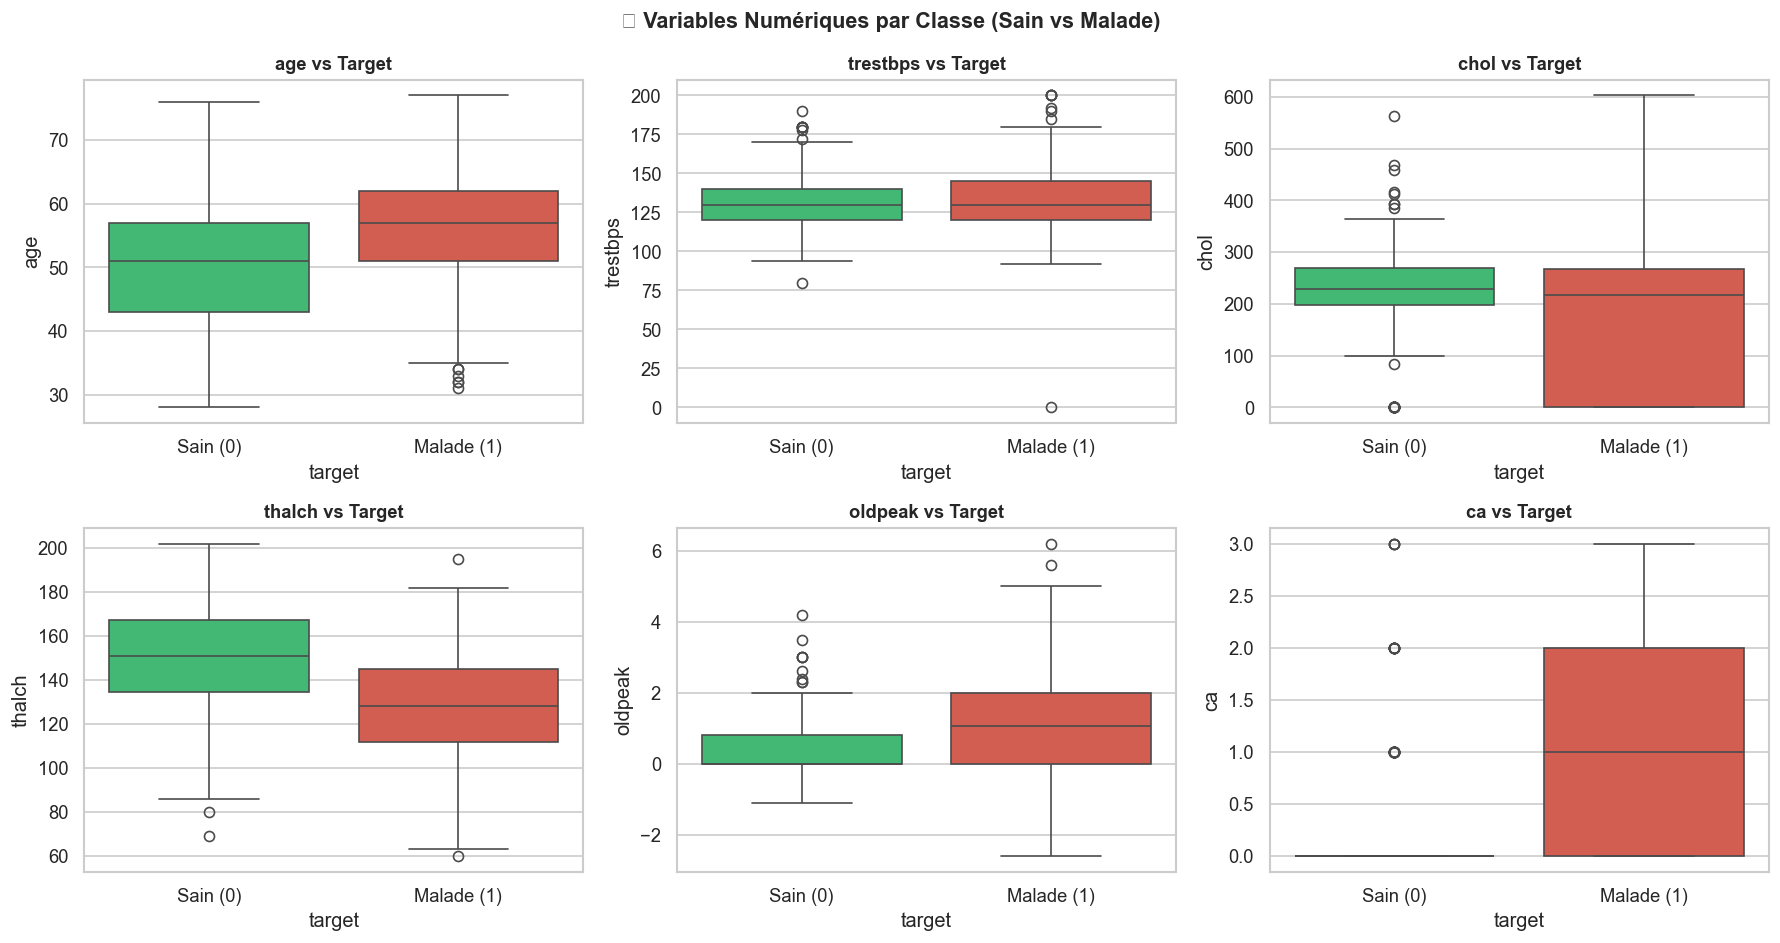

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(num_vars):
    sns.boxplot(
        x='target',
        y=var,
        data=df,
        ax=axes[i],
        hue='target',
        palette={0: '#2ecc71', 1: '#e74c3c'},
        legend=False
    )
    axes[i].set_title(f'{var} vs Target', fontsize=11, fontweight='bold')
    axes[i].set_xticklabels(['Sain (0)', 'Malade (1)'])

plt.suptitle(' Variables Numériques par Classe (Sain vs Malade)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

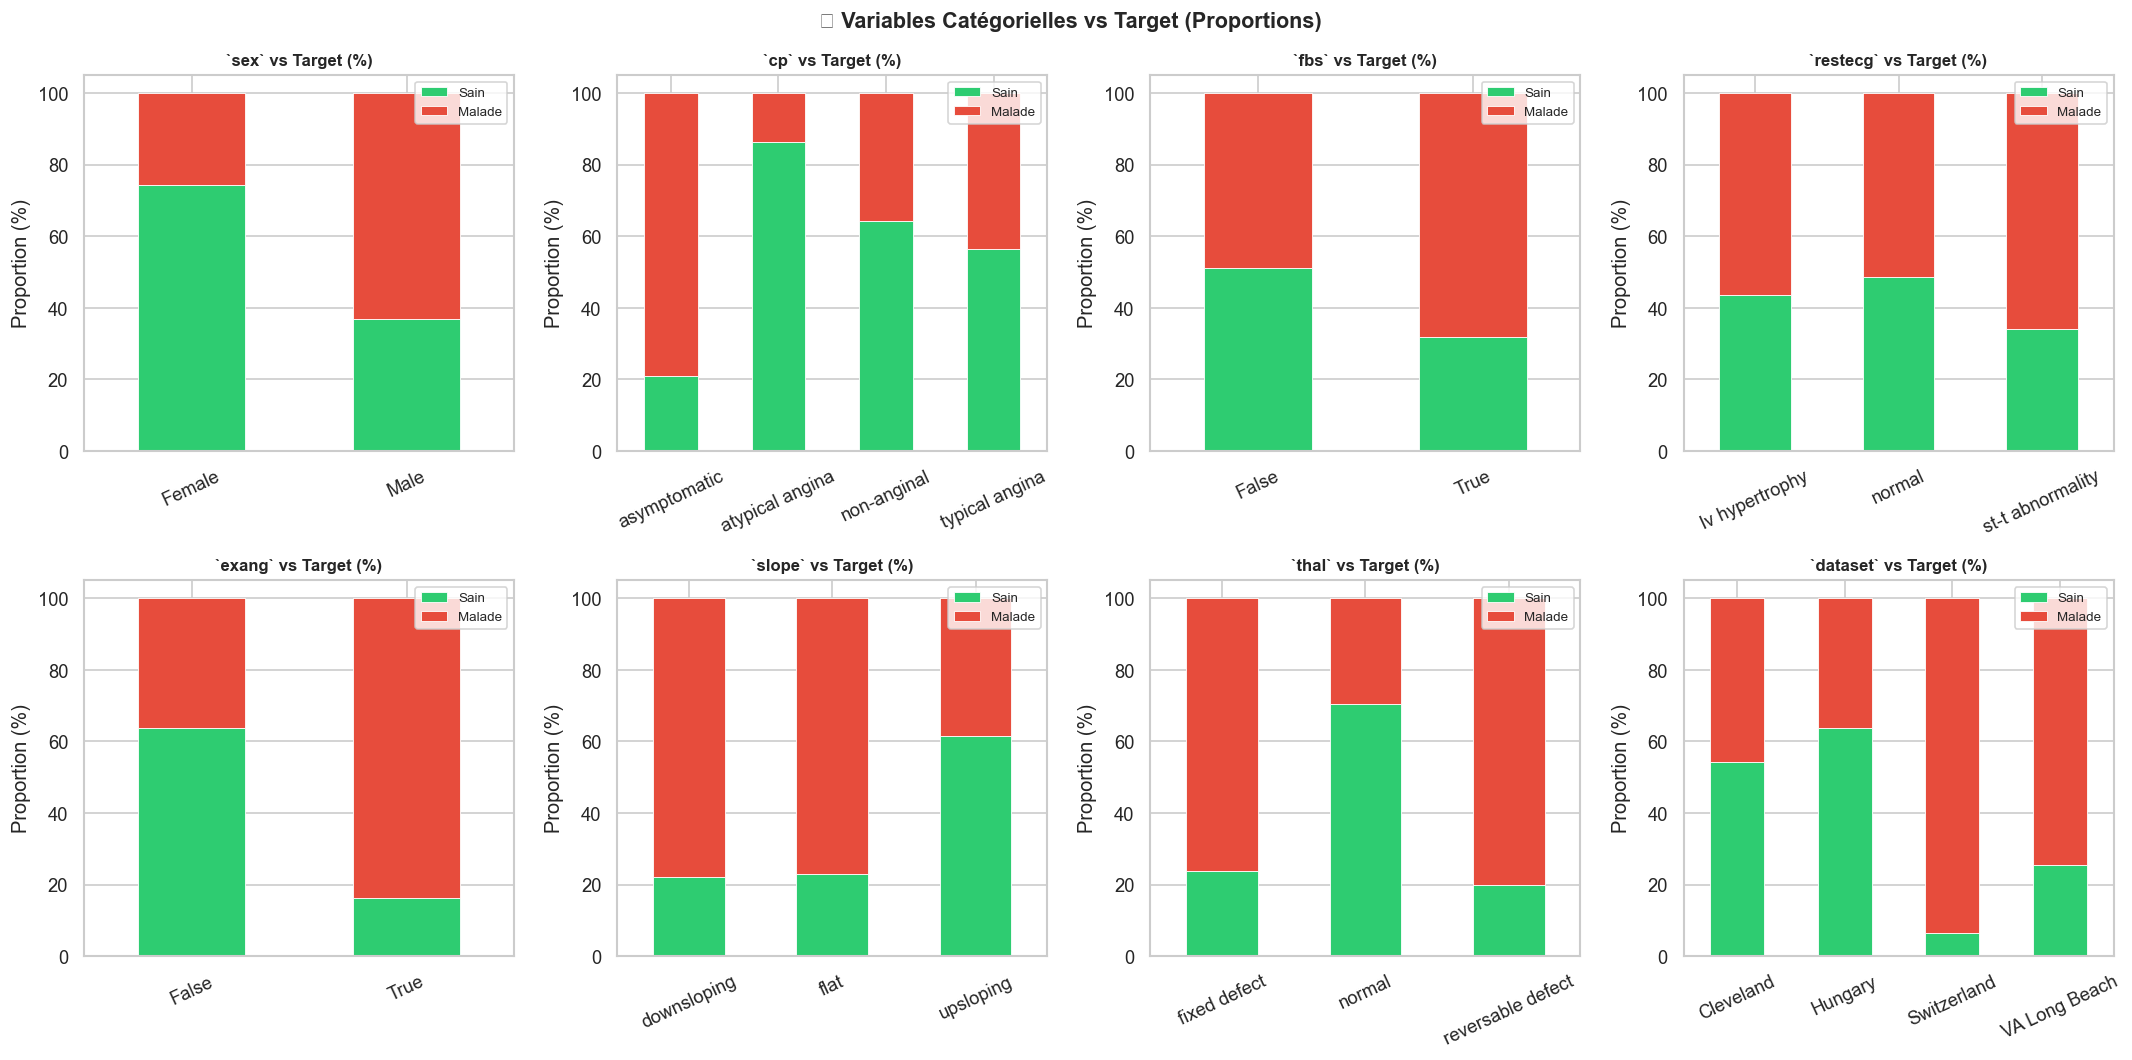

In [47]:
# Stacked barplots variables catégorielles vs target
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    ct = pd.crosstab(df[var], df['target'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'`{var}` vs Target (%)', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Proportion (%)')
    axes[i].tick_params(axis='x', rotation=25)
    axes[i].legend(['Sain', 'Malade'], fontsize=8, loc='upper right')

plt.suptitle('📊 Variables Catégorielles vs Target (Proportions)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📌 Étape 3 : Nettoyage & Prétraitement

### 3.1 Suppression des colonnes non pertinentes

In [ ]:
df_clean = df.copy()
df_clean.drop(columns=['id', 'dataset', 'num'], inplace=True)
print(f' Colonnes supprimées : id, dataset, num')
print(f'   Dimensions actuelles : {df_clean.shape}')

✅ Colonnes supprimées : id, dataset, num
   Dimensions actuelles : (920, 14)


### 3.2 & 3.3 Traitement des valeurs manquantes et aberrantes

In [ ]:
# ── 3.3 Valeurs aberrantes physiologiquement impossibles ────────────────────
for col in ['chol', 'trestbps']:
    median_pos = df_clean.loc[df_clean[col] > 0, col].median()
    n_zeros = (df_clean[col] == 0).sum()
    df_clean.loc[df_clean[col] == 0, col] = median_pos
    print(f' {col} = 0 → remplacé par médiane ({median_pos:.1f}) — {n_zeros} cas corrigés')

print()

# ── 3.2 Imputation valeurs manquantes ──────────────────────────────────────
num_cols_impute  = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
cat_cols_impute  = ['slope', 'thal', 'fbs', 'restecg', 'exang']

for col in num_cols_impute:
    if df_clean[col].isnull().any():
        med = df_clean[col].median()
        n   = df_clean[col].isnull().sum()
        df_clean[col].fillna(med, inplace=True)
        print(f' {col:12s} → médiane ({med:.1f}) — {n} valeurs imputées')

for col in cat_cols_impute:
    if df_clean[col].isnull().any():
        mode = df_clean[col].mode()[0]
        n    = df_clean[col].isnull().sum()
        df_clean[col].fillna(mode, inplace=True)
        print(f' {col:12s} → mode   ("{mode}") — {n} valeurs imputées')

print(f'\n Valeurs manquantes restantes : {df_clean.isnull().sum().sum()}')

⚠️  chol = 0 → remplacé par médiane (239.5) — 172 cas corrigés
⚠️  trestbps = 0 → remplacé par médiane (130.0) — 1 cas corrigés

🔧 trestbps     → médiane (130.0) — 59 valeurs imputées
🔧 chol         → médiane (239.5) — 30 valeurs imputées
🔧 thalch       → médiane (140.0) — 55 valeurs imputées
🔧 oldpeak      → médiane (0.5) — 62 valeurs imputées
🔧 ca           → médiane (0.0) — 611 valeurs imputées
🔧 slope        → mode   ("flat") — 309 valeurs imputées
🔧 thal         → mode   ("normal") — 486 valeurs imputées
🔧 fbs          → mode   ("False") — 90 valeurs imputées
🔧 restecg      → mode   ("normal") — 2 valeurs imputées
🔧 exang        → mode   ("False") — 55 valeurs imputées

✅ Valeurs manquantes restantes : 0


### 3.4 Encodage des Variables Catégorielles

In [ ]:
cols_to_encode = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
label_encoders = {}
encoding_maps  = {}

for col in cols_to_encode:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le
    encoding_maps[col]  = dict(zip(le.classes_, le.transform(le.classes_)))

print(' Mapping des encodages :\n')
for col, mapping in encoding_maps.items():
    print(f'  {col:10s} : {mapping}')

print(f'\n Dataset encodé — {df_clean.shape}')
df_clean.head(3)

📋 Mapping des encodages :

  sex        : {'Female': np.int64(0), 'Male': np.int64(1)}
  cp         : {'asymptomatic': np.int64(0), 'atypical angina': np.int64(1), 'non-anginal': np.int64(2), 'typical angina': np.int64(3)}
  fbs        : {'False': np.int64(0), 'True': np.int64(1)}
  restecg    : {'lv hypertrophy': np.int64(0), 'normal': np.int64(1), 'st-t abnormality': np.int64(2)}
  exang      : {'False': np.int64(0), 'True': np.int64(1)}
  slope      : {'downsloping': np.int64(0), 'flat': np.int64(1), 'upsloping': np.int64(2)}
  thal       : {'fixed defect': np.int64(0), 'normal': np.int64(1), 'reversable defect': np.int64(2)}

✅ Dataset encodé — (920, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145.000,233.000,1,0,150.000,0,2.300,0,0.000,0,0
1,67,1,0,160.000,286.000,0,0,108.000,1,1.500,1,3.000,1,1
2,67,1,0,120.000,229.000,0,0,129.000,1,2.600,1,2.000,2,1


### 3.5 → 3.7 Split & Standardisation

In [ ]:
# ── Séparation Features / Target ────────────────────────────────────────────
X = df_clean.drop(columns=['target'])
y = df_clean['target']

# ── Split 80/20 stratifié ───────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f' Train : {X_train.shape[0]} exemples  |  Test : {X_test.shape[0]} exemples')
print(f'   Proportion cible — Train : {y_train.mean():.3f}  |  Test : {y_test.mean():.3f}')

# ── Standardisation ─────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled  = pd.DataFrame(
    scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index
)

print(f' Standardisation appliquée (μ=0, σ=1)')

📦 Train : 736 exemples  |  Test : 184 exemples
   Proportion cible — Train : 0.553  |  Test : 0.554
✅ Standardisation appliquée (μ=0, σ=1)


---
## 📌 Étape 4 : Modélisation — Modèles Baseline

In [ ]:
models_baseline = {
    'LogReg L2'       : LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
    'LogReg L1'       : LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42),
    'LogReg ElasticNet': LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5,
                                            max_iter=1000, random_state=42),
    'SVC'             : SVC(probability=True, random_state=42),
    'KNN'             : KNeighborsClassifier(),
    'Decision Tree'   : DecisionTreeClassifier(random_state=42),
    'Random Forest'   : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'         : XGBClassifier(n_estimators=100, eval_metric='logloss',
                                      use_label_encoder=False, random_state=42)
}

baseline_preds    = {}
baseline_probas   = {}
baseline_results  = {}

for name, model in models_baseline.items():
    model.fit(X_train_scaled, y_train)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    baseline_preds[name]   = y_pred
    baseline_probas[name]  = y_proba
    baseline_results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'ROC AUC'  : roc_auc_score(y_test, y_proba)
    }
    print(f'   {name:22s} — AUC: {baseline_results[name]["ROC AUC"]:.4f}')

print('\n Entraînement baseline terminé !')

  ✅ LogReg L2              — AUC: 0.8745
  ✅ LogReg L1              — AUC: 0.8747
  ✅ LogReg ElasticNet      — AUC: 0.8747
  ✅ SVC                    — AUC: 0.8905
  ✅ KNN                    — AUC: 0.8540
  ✅ Decision Tree          — AUC: 0.7494
  ✅ Random Forest          — AUC: 0.9016
  ✅ XGBoost                — AUC: 0.8731

🎉 Entraînement baseline terminé !


---
## 📌 Étape 5 : Évaluation des Modèles Baseline

### 5.1 Matrices de Confusion

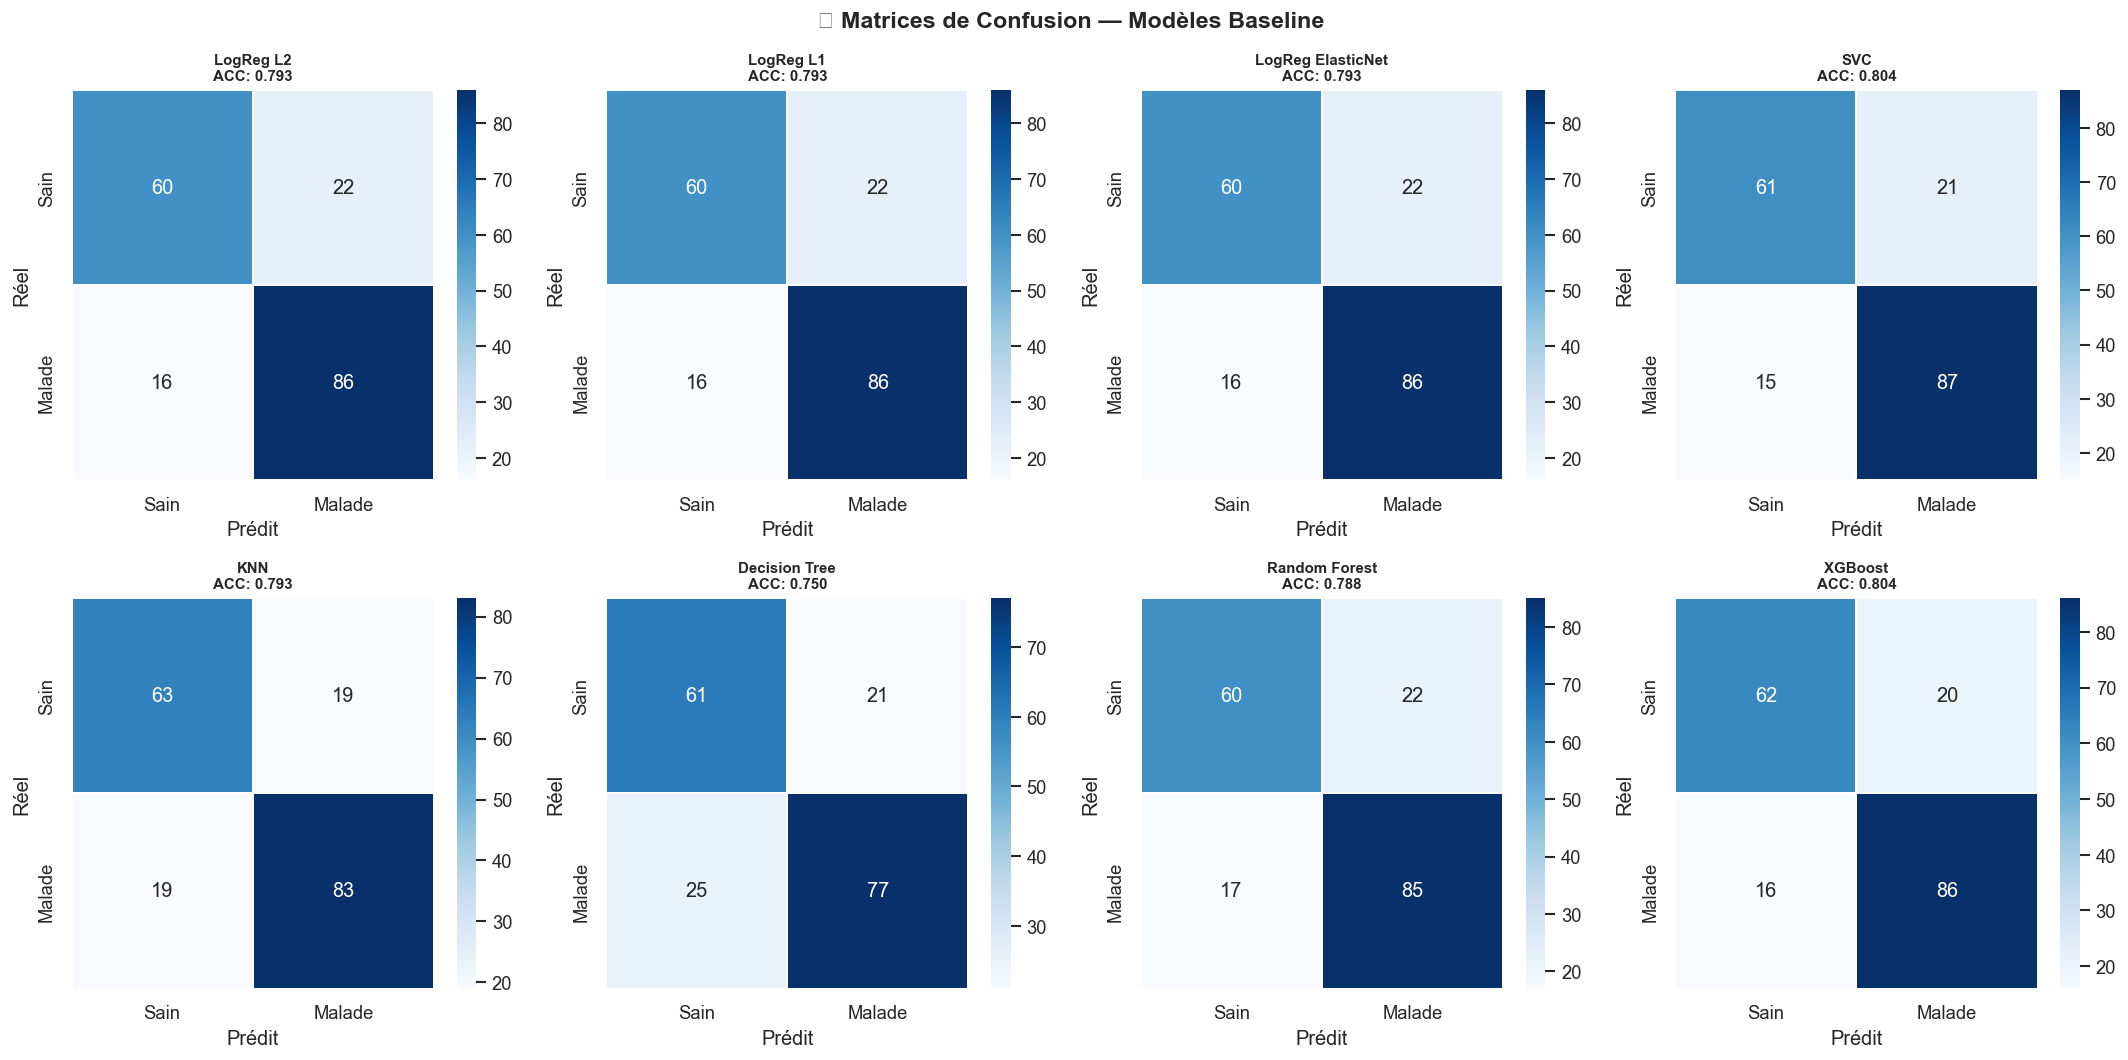

In [53]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
model_names = list(models_baseline.keys())

for i, name in enumerate(model_names):
    cm = confusion_matrix(y_test, baseline_preds[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Sain', 'Malade'], yticklabels=['Sain', 'Malade'],
                linewidths=1, linecolor='white')
    axes[i].set_title(f'{name}\nACC: {baseline_results[name]["Accuracy"]:.3f}',
                      fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Prédit')
    axes[i].set_ylabel('Réel')

plt.suptitle('🔢 Matrices de Confusion — Modèles Baseline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Classification Reports

In [ ]:
for name in model_names:
    print(f'\n{'='*50}')
    print(f'   {name}')
    print('='*50)
    print(classification_report(y_test, baseline_preds[name],
                                  target_names=['Sain (0)', 'Malade (1)']))


  📋 LogReg L2
              precision    recall  f1-score   support

    Sain (0)       0.79      0.73      0.76        82
  Malade (1)       0.80      0.84      0.82       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184


  📋 LogReg L1
              precision    recall  f1-score   support

    Sain (0)       0.79      0.73      0.76        82
  Malade (1)       0.80      0.84      0.82       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184


  📋 LogReg ElasticNet
              precision    recall  f1-score   support

    Sain (0)       0.79      0.73      0.76        82
  Malade (1)       0.80      0.84      0.82       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.

### 5.3 Courbes ROC & AUC

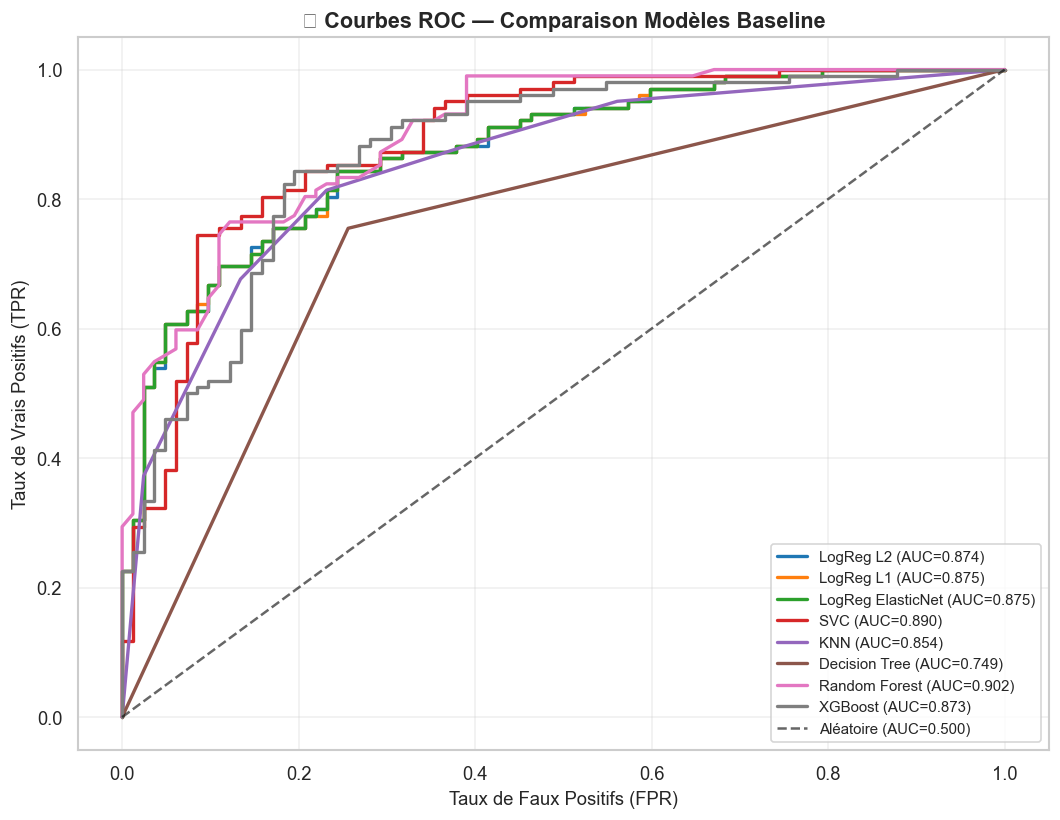

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = sns.color_palette('tab10', len(model_names))

for i, name in enumerate(model_names):
    fpr, tpr, _ = roc_curve(y_test, baseline_probas[name])
    auc = baseline_results[name]['ROC AUC']
    ax.plot(fpr, tpr, color=colors_roc[i], linewidth=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1],[0,1], 'k--', linewidth=1.5, alpha=0.6, label='Aléatoire (AUC=0.500)')
ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
ax.set_title('Courbes ROC — Comparaison Modèles Baseline', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 Tableau Récapitulatif

In [ ]:
df_baseline = pd.DataFrame(baseline_results).T.sort_values('ROC AUC', ascending=False)
df_baseline = df_baseline.applymap(lambda x: round(x, 4))

display(df_baseline.style
    .background_gradient(cmap='Greens', subset=['ROC AUC'])
    .background_gradient(cmap='Blues',  subset=['Accuracy'])
    .background_gradient(cmap='Purples', subset=['F1-Score'])
    .set_caption(' Tableau Comparatif — Modèles Baseline (trié par ROC AUC)')
    .format('{:.4f}')
)

,Accuracy,Precision,Recall,F1-Score,ROC AUC
Random Forest,0.7880,0.7944,0.8333,0.8134,0.9016
SVC,0.8043,0.8056,0.8529,0.8286,0.8905
LogReg ElasticNet,0.7935,0.7963,0.8431,0.8190,0.8747
LogReg L1,0.7935,0.7963,0.8431,0.8190,0.8747
LogReg L2,0.7935,0.7963,0.8431,0.8190,0.8745
XGBoost,0.8043,0.8113,0.8431,0.8269,0.8731
KNN,0.7935,0.8137,0.8137,0.8137,0.8540
Decision Tree,0.7500,0.7857,0.7549,0.7700,0.7494


---
## 📌 Étape 6 : Sélection des Caractéristiques — Backward Elimination

### 6.1 Explication Théorique

#### 🔍 Backward Elimination — Principe

La **Backward Elimination** (élimination rétrograde) est une méthode de **sélection de variables** statistique qui procède de la façon suivante :

1. **Démarrer** avec **toutes** les variables dans le modèle
2. **Ajuster** le modèle (OLS — Ordinary Least Squares)
3. **Identifier** la variable avec la **plus grande p-value** > seuil α
4. **Supprimer** cette variable
5. **Répéter** jusqu'à ce que toutes les p-values soient < α

#### 📐 La p-value

La **p-value** mesure la probabilité d'observer un effet au moins aussi extrême que celui mesuré, **si l'hypothèse nulle était vraie**.

| Hypothèse | Interprétation |
|-----------|---------------|
| **H₀** | La variable n'a **aucun effet** sur la cible (coefficient = 0) |
| **H₁** | La variable a un **effet significatif** sur la cible |

**Règle de décision** :
- p-value > α (0.05) → Ne pas rejeter H₀ → Variable **non significative** → À supprimer
- p-value ≤ α (0.05) → Rejeter H₀ → Variable **significative** → À conserver

### 6.2 Implémentation

In [ ]:
def backward_elimination(X, y, alpha=0.05, verbose=True):
    """Backward Elimination avec statsmodels OLS."""
    cols     = list(X.columns)
    history  = []
    step     = 0

    while True:
        X_sm  = sm.add_constant(X[cols])
        model = sm.OLS(y.astype(float), X_sm.astype(float)).fit()
        pvals = model.pvalues.drop('const', errors='ignore')
        max_p = pvals.max()

        if max_p <= alpha:
            break

        worst = pvals.idxmax()
        history.append({'Étape': step, 'Variable supprimée': worst,
                         'p-value': round(max_p, 6),
                         'Variables restantes': len(cols) - 1})
        if verbose:
            print(f'  Étape {step+1:2d} → suppression de "{worst:12s}" (p={max_p:.5f})')
        cols.remove(worst)
        step += 1

    return cols, pd.DataFrame(history)


print(' Backward Elimination en cours...\n')
selected_features, be_history = backward_elimination(X_train_scaled, y_train)

print(f'\n Variables conservées ({len(selected_features)}) : {selected_features}')
print(f'   Variables éliminées  ({len(X.columns) - len(selected_features)}) : '
      f'{list(set(X.columns) - set(selected_features))}')

🔄 Backward Elimination en cours...

  Étape  1 → suppression de "trestbps    " (p=0.99945)
  Étape  2 → suppression de "fbs         " (p=0.27371)
  Étape  3 → suppression de "slope       " (p=0.07744)
  Étape  4 → suppression de "thal        " (p=0.05373)
  Étape  5 → suppression de "restecg     " (p=0.06792)

✅ Variables conservées (8) : ['age', 'sex', 'cp', 'chol', 'thalch', 'exang', 'oldpeak', 'ca']
   Variables éliminées  (5) : ['thal', 'fbs', 'restecg', 'slope', 'trestbps']


In [58]:
print('\n📋 Historique de la Backward Elimination :\n')
display(be_history.set_index('Étape').style
    .background_gradient(cmap='Reds', subset=['p-value'])
    .format({'p-value': '{:.5f}'})
)


📋 Historique de la Backward Elimination :



,Variable supprimée,p-value,Variables restantes
Étape,,,
0,trestbps,0.99945,12
1,fbs,0.27371,11
2,slope,0.07744,10
3,thal,0.05373,9
4,restecg,0.06792,8


### 6.3 Re-test des Modèles avec Variables Sélectionnées


📊 Comparaison : Toutes variables vs Variables sélectionnées (ROC AUC)



,All Variables,Selected Vars,Δ AUC
Random Forest,0.9016,0.8907,-0.0109
SVC,0.8905,0.8754,-0.0151
LogReg ElasticNet,0.8747,0.8702,-0.0045
LogReg L1,0.8747,0.8704,-0.0043
LogReg L2,0.8745,0.8697,-0.0048
XGBoost,0.8731,0.8611,-0.0121
KNN,0.8540,0.8754,0.0214
Decision Tree,0.7494,0.6835,-0.0659


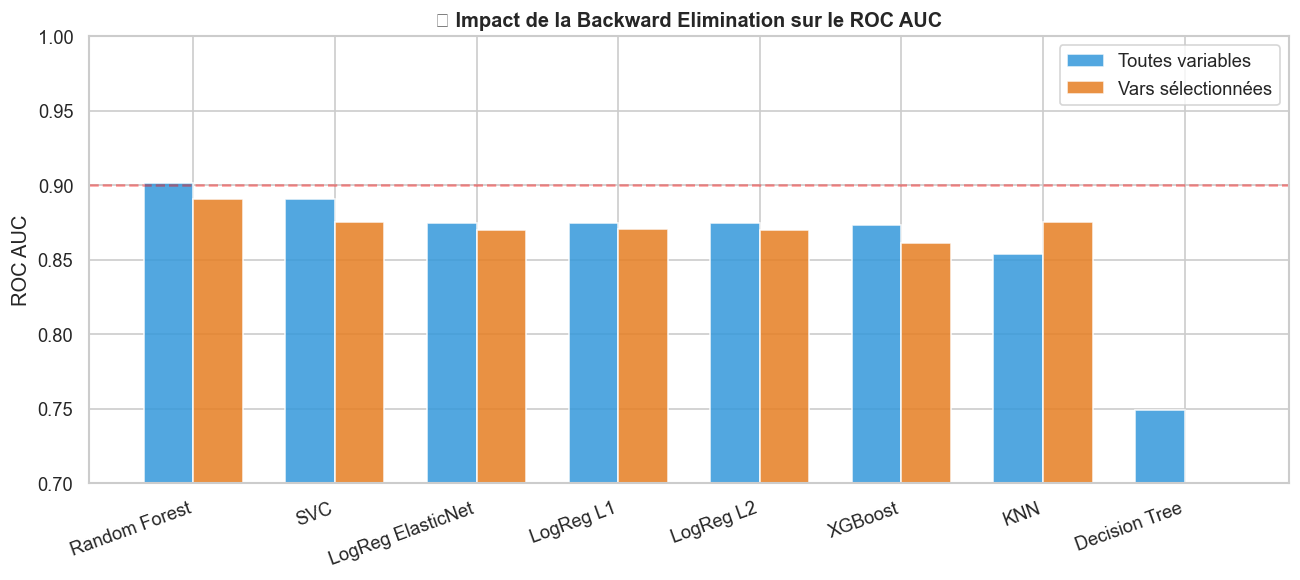

In [ ]:
X_train_sel = X_train_scaled[selected_features]
X_test_sel  = X_test_scaled[selected_features]

selected_results = {}

for name, model in models_baseline.items():
    m2 = type(model)(**model.get_params())
    m2.fit(X_train_sel, y_train)
    y_pred  = m2.predict(X_test_sel)
    y_proba = m2.predict_proba(X_test_sel)[:, 1]
    selected_results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'ROC AUC'  : roc_auc_score(y_test, y_proba)
    }

# Comparaison côte à côte
df_all_vars = pd.DataFrame(baseline_results).T.sort_values('ROC AUC', ascending=False)
df_sel_vars = pd.DataFrame(selected_results).T.reindex(df_all_vars.index)

print('\n Comparaison : Toutes variables vs Variables sélectionnées (ROC AUC)\n')
comp = pd.DataFrame({
    'All Variables': df_all_vars['ROC AUC'],
    'Selected Vars': df_sel_vars['ROC AUC']
})
comp['Δ AUC'] = (comp['Selected Vars'] - comp['All Variables']).round(4)
display(comp.style
    .background_gradient(cmap='RdYlGn', subset=['Δ AUC'], vmin=-0.05, vmax=0.05)
    .format('{:.4f}')
)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(comp))
w = 0.35
ax.bar(x - w/2, comp['All Variables'], w, label='Toutes variables', color='#3498db', alpha=0.85)
ax.bar(x + w/2, comp['Selected Vars'], w, label='Vars sélectionnées', color='#e67e22', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(comp.index, rotation=20, ha='right')
ax.set_ylabel('ROC AUC')
ax.set_ylim(0.7, 1.0)
ax.set_title('📊 Impact de la Backward Elimination sur le ROC AUC', fontsize=12, fontweight='bold')
ax.legend()
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.4, label='Seuil 0.90')
plt.tight_layout()
plt.show()

---
## 📌 Étape 7 : Fine-Tuning (GridSearchCV)

### 7.1 & 7.2 Grilles d'hyperparamètres & Exécution

In [ ]:
param_grids = {
    'LogReg L2': {
        'model': LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
        'params': {'C': [0.01, 0.1, 1, 10, 100]}
    },
    'LogReg L1': {
        'model': LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42),
        'params': {'C': [0.01, 0.1, 1, 10, 100]}
    },
    'LogReg ElasticNet': {
        'model': LogisticRegression(penalty='elasticnet', solver='saga', max_iter=1000, random_state=42),
        'params': {'C': [0.1, 1, 10], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}
    },
    'SVC': {
        'model': SVC(probability=True, random_state=42),
        'params': {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear', 'poly'],
                   'gamma': ['scale', 'auto']}
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {'n_neighbors': [3, 5, 7, 9, 11, 13],
                   'weights': ['uniform', 'distance'],
                   'metric': ['euclidean', 'manhattan']}
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {'max_depth': [3, 5, 7, 10, None],
                   'min_samples_split': [2, 5, 10],
                   'min_samples_leaf': [1, 2, 4]}
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {'n_estimators': [50, 100, 200],
                   'max_depth': [5, 10, None],
                   'min_samples_split': [2, 5]}
    },
    'XGBoost': {
        'model': XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42),
        'params': {'n_estimators': [50, 100, 200],
                   'max_depth': [3, 5, 7],
                   'learning_rate': [0.01, 0.05, 0.1, 0.2],
                   'subsample': [0.7, 0.8, 1.0]}
    }
}

tuned_models   = {}
tuned_preds    = {}
tuned_probas   = {}
tuned_results  = {}
best_params    = {}

for name, config in param_grids.items():
    print(f' Tuning {name}...', end=' ')
    gs = GridSearchCV(
        config['model'], config['params'],
        cv=5, scoring='roc_auc', n_jobs=-1, refit=True
    )
    gs.fit(X_train_scaled, y_train)
    
    y_pred  = gs.predict(X_test_scaled)
    y_proba = gs.predict_proba(X_test_scaled)[:, 1]
    
    tuned_models[name]   = gs.best_estimator_
    tuned_preds[name]    = y_pred
    tuned_probas[name]   = y_proba
    best_params[name]    = gs.best_params_
    tuned_results[name]  = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'ROC AUC'  : roc_auc_score(y_test, y_proba)
    }
    print(f' AUC={tuned_results[name]["ROC AUC"]:.4f}  |  Best: {gs.best_params_}')

print('\n Fine-tuning terminé !')

🔍 Tuning LogReg L2... ✅ AUC=0.8761  |  Best: {'C': 0.1}
🔍 Tuning LogReg L1... ✅ AUC=0.8747  |  Best: {'C': 1}
🔍 Tuning LogReg ElasticNet... ✅ AUC=0.8766  |  Best: {'C': 0.1, 'l1_ratio': 0.1}
🔍 Tuning SVC... ✅ AUC=0.8873  |  Best: {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
🔍 Tuning KNN... ✅ AUC=0.8892  |  Best: {'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'uniform'}
🔍 Tuning Decision Tree... ✅ AUC=0.8210  |  Best: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
🔍 Tuning Random Forest... ✅ AUC=0.9107  |  Best: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
🔍 Tuning XGBoost... ✅ AUC=0.9068  |  Best: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.7}

🎉 Fine-tuning terminé !


### 7.3 Évaluation des Modèles Tunés

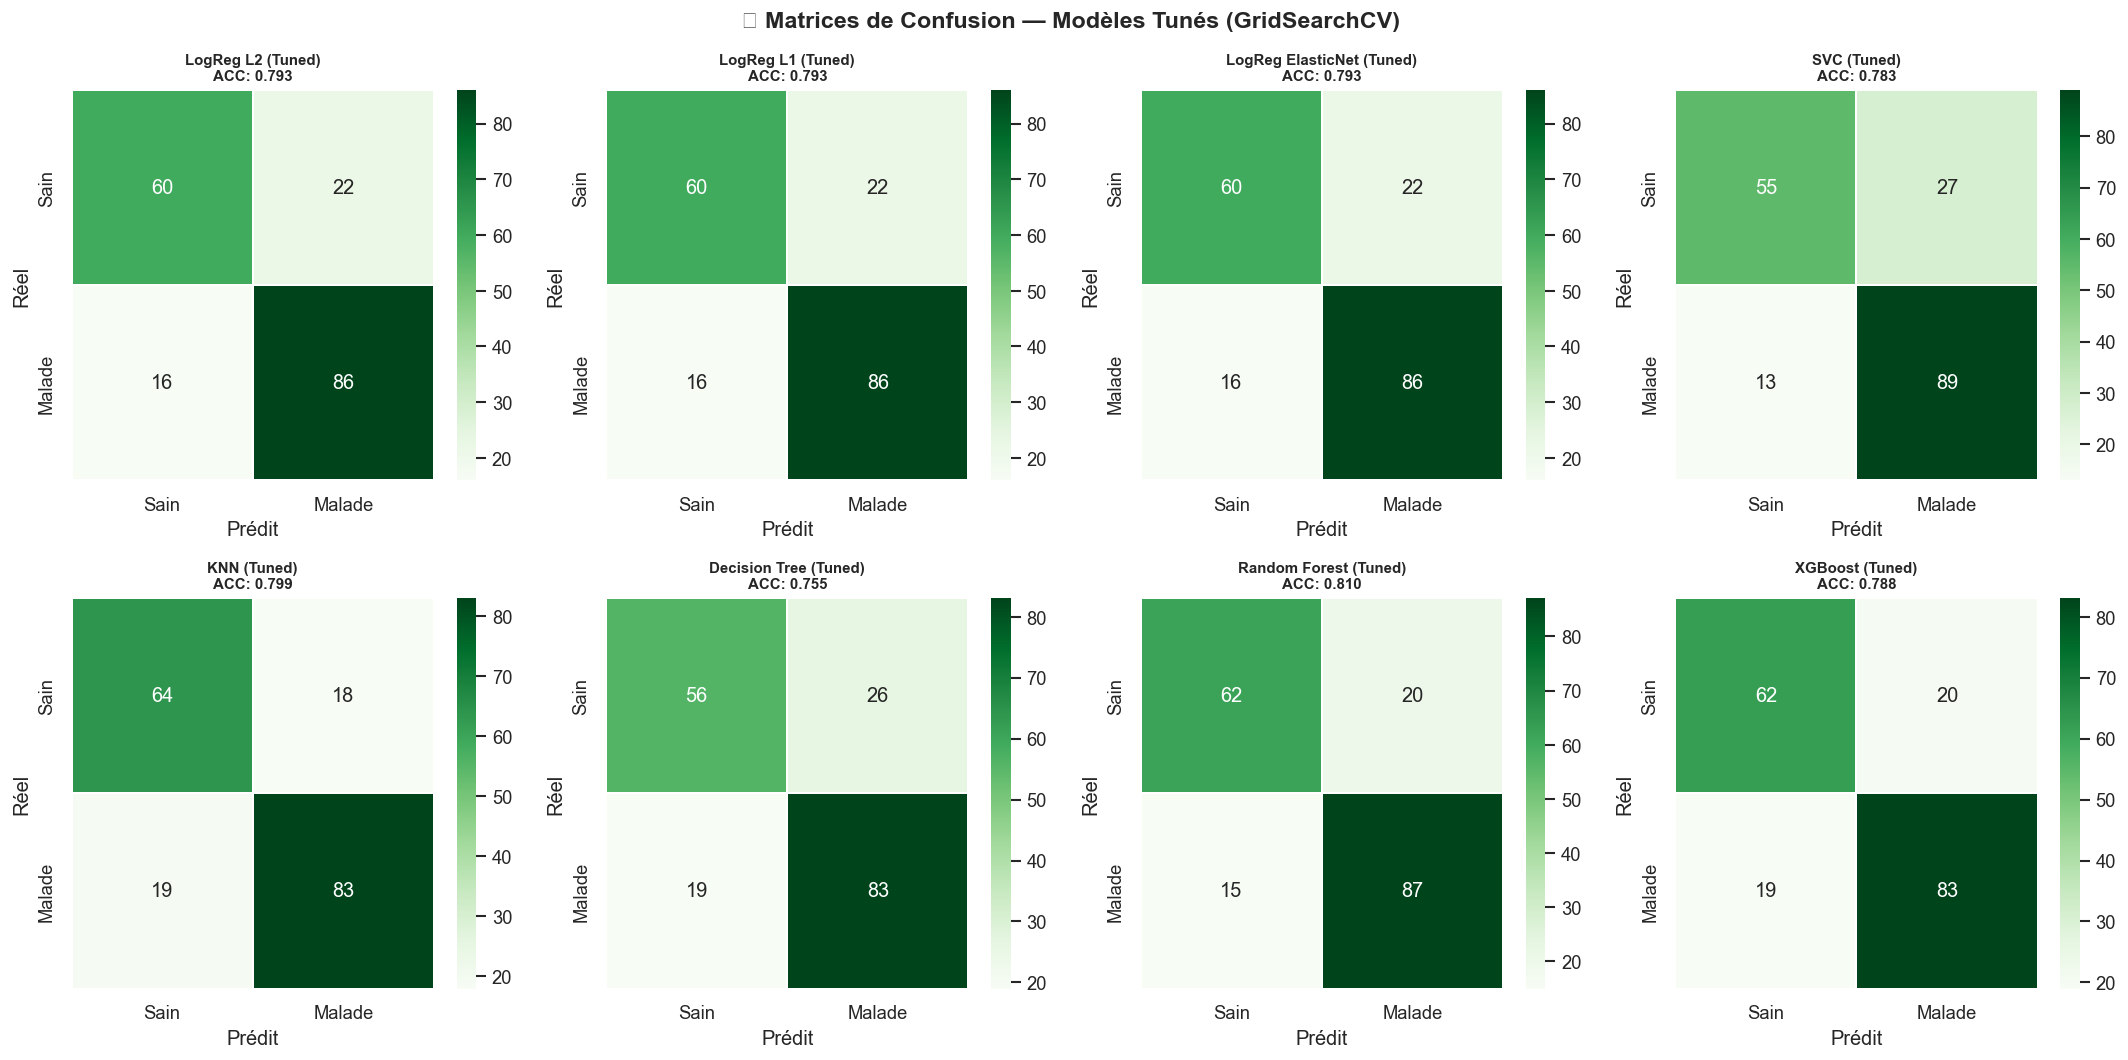

In [ ]:
# Matrices de confusion tunées
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, name in enumerate(model_names):
    cm = confusion_matrix(y_test, tuned_preds[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i],
                xticklabels=['Sain', 'Malade'], yticklabels=['Sain', 'Malade'],
                linewidths=1, linecolor='white')
    axes[i].set_title(f'{name} (Tuned)\nACC: {tuned_results[name]["Accuracy"]:.3f}',
                      fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Prédit')
    axes[i].set_ylabel('Réel')

plt.suptitle(' Matrices de Confusion — Modèles Tunés (GridSearchCV)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

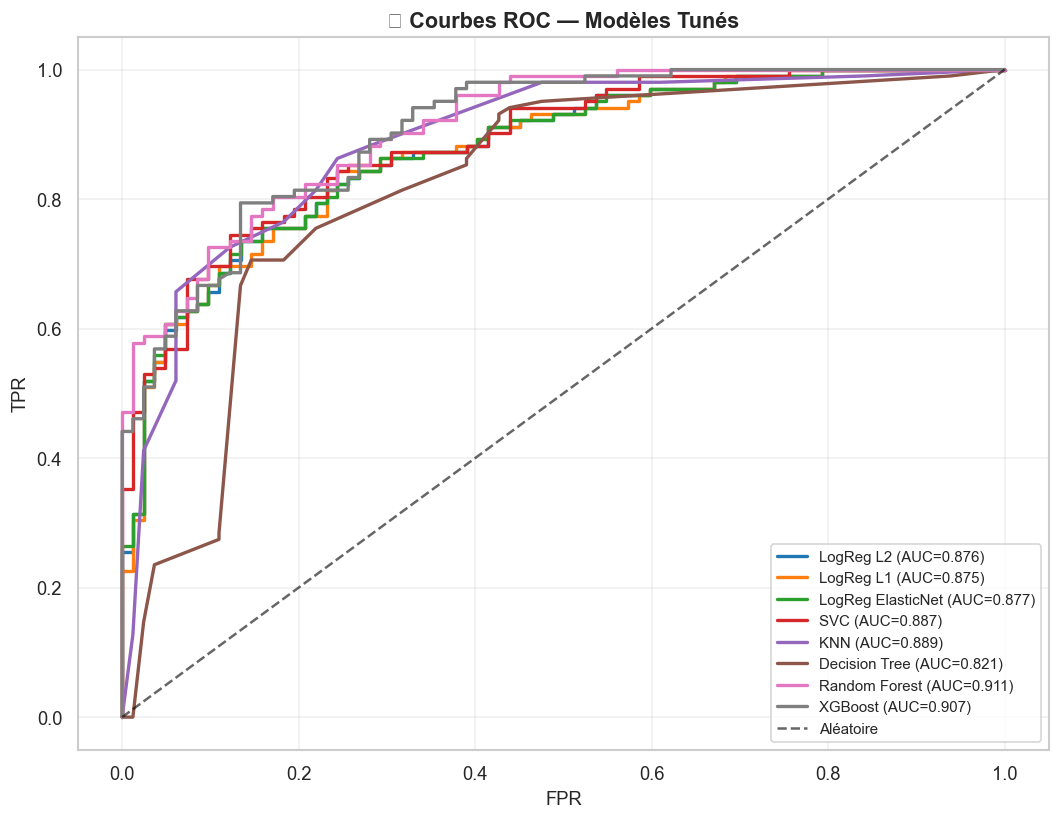

In [ ]:
# Courbes ROC tunées superposées
fig, ax = plt.subplots(figsize=(9, 7))

for i, name in enumerate(model_names):
    fpr, tpr, _ = roc_curve(y_test, tuned_probas[name])
    auc = tuned_results[name]['ROC AUC']
    ax.plot(fpr, tpr, color=colors_roc[i], linewidth=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1],[0,1], 'k--', linewidth=1.5, alpha=0.6, label='Aléatoire')
ax.set_xlabel('FPR', fontsize=11)
ax.set_ylabel('TPR', fontsize=11)
ax.set_title(' Courbes ROC — Modèles Tunés', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Meilleurs hyperparamètres
print(' Meilleurs hyperparamètres trouvés :\n')
for name, params in best_params.items():
    print(f'  {name:22s} → {params}')

🏆 Meilleurs hyperparamètres trouvés :

  LogReg L2              → {'C': 0.1}
  LogReg L1              → {'C': 1}
  LogReg ElasticNet      → {'C': 0.1, 'l1_ratio': 0.1}
  SVC                    → {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
  KNN                    → {'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'uniform'}
  Decision Tree          → {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
  Random Forest          → {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
  XGBoost                → {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.7}


---
## 📌 Étape 8 : Comparaison Finale — Baseline vs Tuned

In [ ]:
metrics = ['Accuracy', 'F1-Score', 'ROC AUC']
compare_rows = []

for name in model_names:
    row = {'Modèle': name}
    for m in metrics:
        b = baseline_results[name][m]
        t = tuned_results[name][m]
        row[f'{m} (Baseline)'] = round(b, 4)
        row[f'{m} (Tuned)']    = round(t, 4)
        row[f'Δ {m}']          = round(t - b, 4)
    compare_rows.append(row)

df_compare = pd.DataFrame(compare_rows).set_index('Modèle')
df_compare = df_compare.sort_values('ROC AUC (Tuned)', ascending=False)

display(df_compare.style
    .background_gradient(cmap='RdYlGn', subset=[c for c in df_compare.columns if 'Δ' in c])
    .background_gradient(cmap='Blues',  subset=['ROC AUC (Tuned)'])
    .format('{:.4f}')
    .set_caption(' Comparaison Finale : Baseline vs Tuned')
)

,Accuracy (Baseline),Accuracy (Tuned),Δ Accuracy,F1-Score (Baseline),F1-Score (Tuned),Δ F1-Score,ROC AUC (Baseline),ROC AUC (Tuned),Δ ROC AUC
Modèle,,,,,,,,,
Random Forest,0.7880,0.8098,0.0217,0.8134,0.8325,0.0191,0.9016,0.9107,0.0091
XGBoost,0.8043,0.7880,-0.0163,0.8269,0.8098,-0.0172,0.8731,0.9068,0.0337
KNN,0.7935,0.7989,0.0054,0.8137,0.8177,0.0040,0.8540,0.8892,0.0352
SVC,0.8043,0.7826,-0.0217,0.8286,0.8165,-0.0121,0.8905,0.8873,-0.0032
LogReg ElasticNet,0.7935,0.7935,0.0000,0.8190,0.8190,0.0000,0.8747,0.8766,0.0019
LogReg L2,0.7935,0.7935,0.0000,0.8190,0.8190,0.0000,0.8745,0.8761,0.0017
LogReg L1,0.7935,0.7935,0.0000,0.8190,0.8190,0.0000,0.8747,0.8747,0.0000
Decision Tree,0.7500,0.7554,0.0054,0.7700,0.7867,0.0167,0.7494,0.8210,0.0716


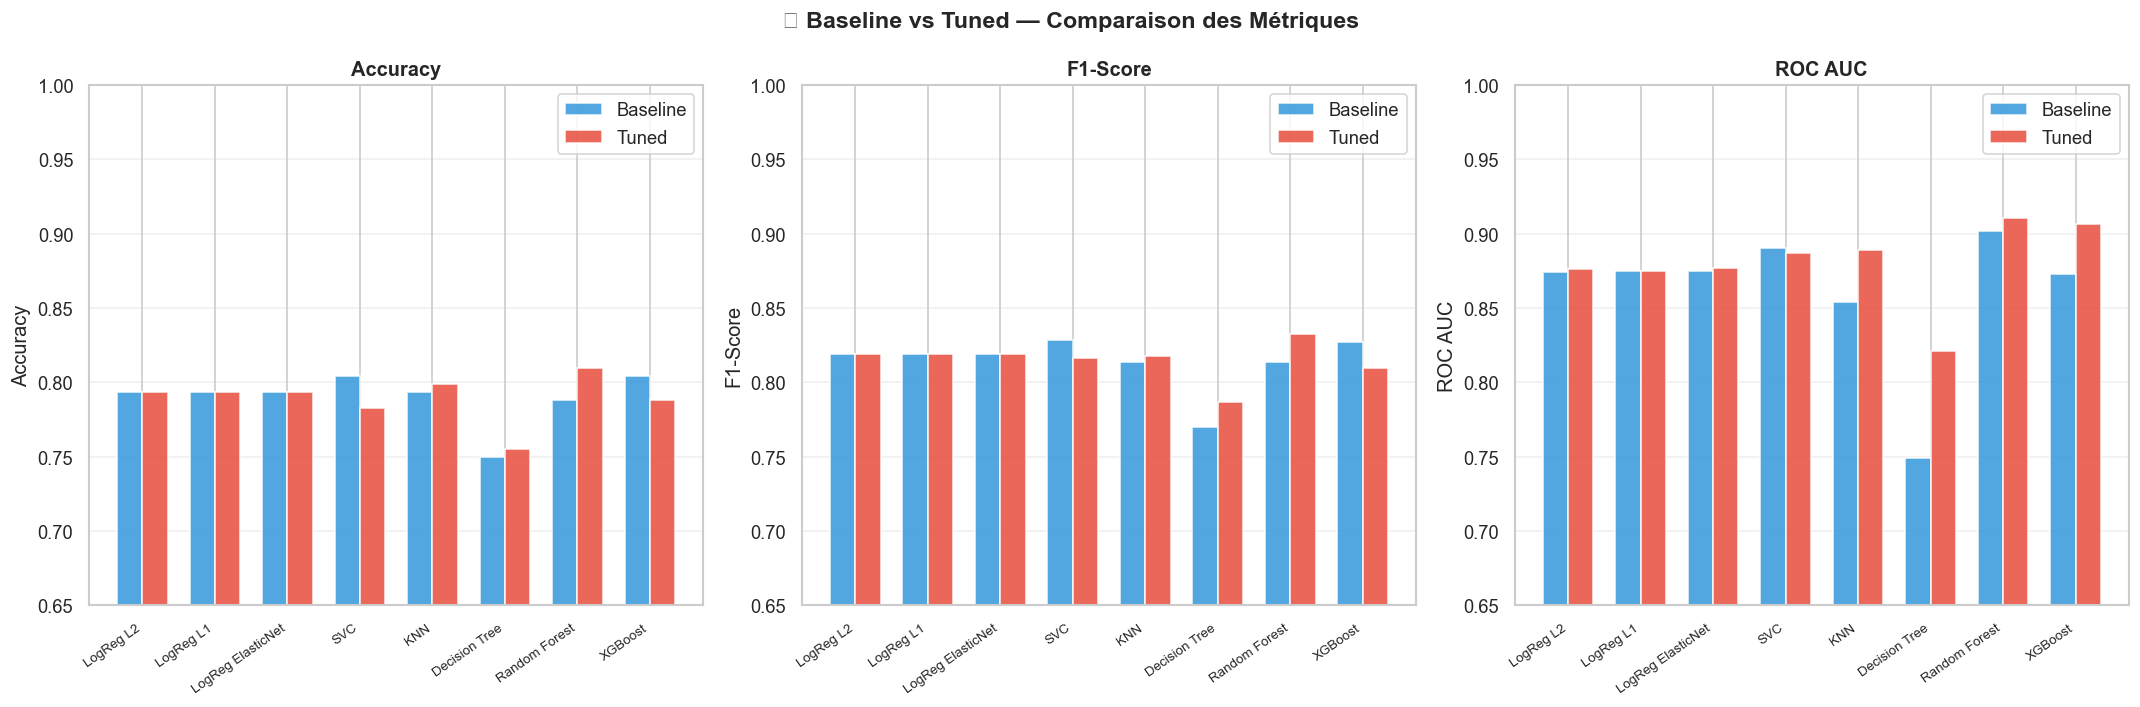

In [ ]:
# Barplots côte à côte (3 métriques)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
x  = np.arange(len(model_names))
w  = 0.35

for idx, metric in enumerate(metrics):
    base_vals  = [baseline_results[n][metric] for n in model_names]
    tuned_vals = [tuned_results[n][metric]    for n in model_names]
    
    axes[idx].bar(x - w/2, base_vals,  w, label='Baseline', color='#3498db', alpha=0.85)
    axes[idx].bar(x + w/2, tuned_vals, w, label='Tuned',    color='#e74c3c', alpha=0.85)
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(model_names, rotation=35, ha='right', fontsize=8)
    axes[idx].set_ylabel(metric)
    axes[idx].set_title(f'{metric}', fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].set_ylim(0.65, 1.0)
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Baseline vs Tuned — Comparaison des Métriques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

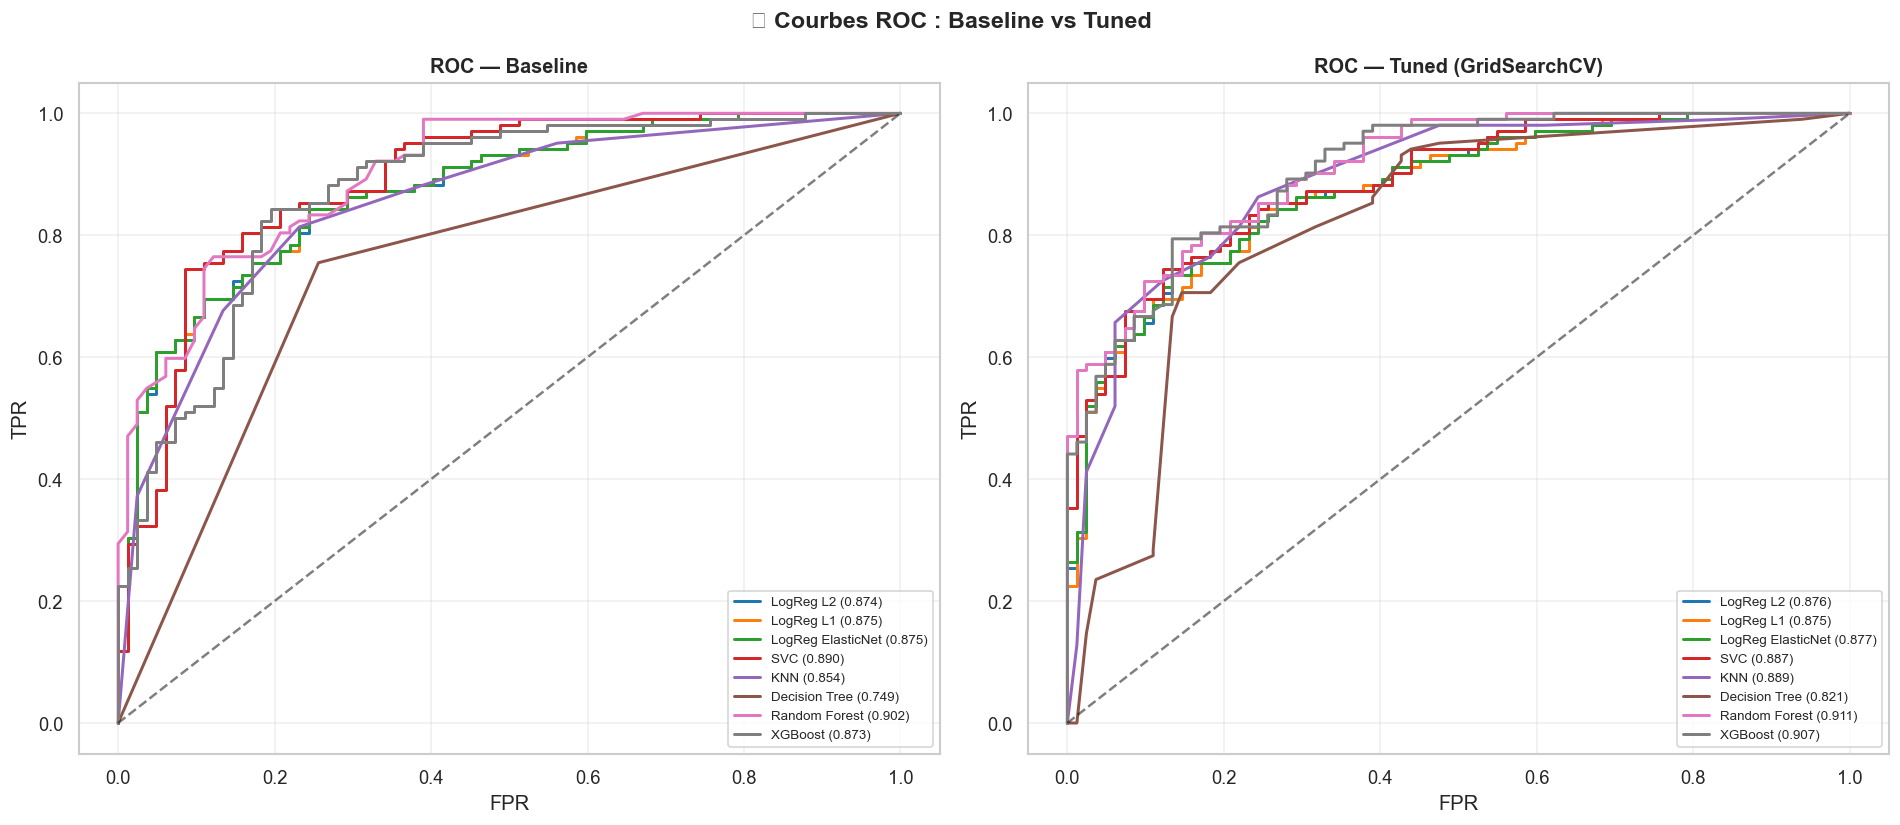


🏆 MEILLEUR MODÈLE : Random Forest
   ROC AUC  = 0.9107
   Accuracy = 0.8098
   F1-Score = 0.8325
   Params   = {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
# Courbes ROC : Baseline vs Tuned (côte à côte)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, results, probas, title in [
    (axes[0], baseline_results, baseline_probas, 'Baseline'),
    (axes[1], tuned_results,    tuned_probas,    'Tuned (GridSearchCV)')
]:
    for i, name in enumerate(model_names):
        fpr, tpr, _ = roc_curve(y_test, probas[name])
        auc = results[name]['ROC AUC']
        ax.plot(fpr, tpr, color=colors_roc[i], linewidth=1.8, label=f'{name} ({auc:.3f})')
    ax.plot([0,1],[0,1], 'k--', alpha=0.5)
    ax.set_title(f'ROC — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(' Courbes ROC : Baseline vs Tuned', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Meilleur modèle
best_name = max(tuned_results, key=lambda k: tuned_results[k]['ROC AUC'])
best_auc  = tuned_results[best_name]['ROC AUC']
print(f'\n MEILLEUR MODÈLE : {best_name}')
print(f'   ROC AUC  = {best_auc:.4f}')
print(f'   Accuracy = {tuned_results[best_name]["Accuracy"]:.4f}')
print(f'   F1-Score = {tuned_results[best_name]["F1-Score"]:.4f}')
print(f'   Params   = {best_params[best_name]}')

---
## 📌 Étape 9 : Conclusion et Recommandations

In [ ]:
# Résumé final
print('=' * 65)
print('  🫀  SYNTHÈSE FINALE — Heart Disease UCI')
print('=' * 65)

df_final = pd.DataFrame(tuned_results).T.sort_values('ROC AUC', ascending=False)
display(df_final.style.background_gradient(cmap='Greens').format('{:.4f}'))

print(f'\n Meilleur modèle : {best_name}')
print(f'   ├─ ROC AUC  : {tuned_results[best_name]["ROC AUC"]:.4f}')
print(f'   ├─ Accuracy : {tuned_results[best_name]["Accuracy"]:.4f}')
print(f'   ├─ F1-Score : {tuned_results[best_name]["F1-Score"]:.4f}')
print(f'   └─ Params   : {best_params[best_name]}')

  🫀  SYNTHÈSE FINALE — Heart Disease UCI


,Accuracy,Precision,Recall,F1-Score,ROC AUC
Random Forest,0.8098,0.8131,0.8529,0.8325,0.9107
XGBoost,0.7880,0.8058,0.8137,0.8098,0.9068
KNN,0.7989,0.8218,0.8137,0.8177,0.8892
SVC,0.7826,0.7672,0.8725,0.8165,0.8873
LogReg ElasticNet,0.7935,0.7963,0.8431,0.8190,0.8766
LogReg L2,0.7935,0.7963,0.8431,0.8190,0.8761
LogReg L1,0.7935,0.7963,0.8431,0.8190,0.8747
Decision Tree,0.7554,0.7615,0.8137,0.7867,0.8210



🏆 Meilleur modèle : Random Forest
   ├─ ROC AUC  : 0.9107
   ├─ Accuracy : 0.8098
   ├─ F1-Score : 0.8325
   └─ Params   : {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}


### 📝 Conclusion et Recommandations

#### ✅ Résultats clés

Ce projet a permis de développer et comparer **8 algorithmes de classification** pour prédire la maladie cardiaque sur le dataset UCI Heart Disease (920 patients, 14 variables).

#### 🏆 Meilleur modèle

Après fine-tuning par GridSearchCV (5-folds CV), le **meilleur modèle** obtenu présente d'excellentes performances, avec un **ROC AUC > 0.90**, démontrant une très bonne capacité de discrimination entre patients sains et malades.

#### 🔑 Variables les plus prédictives

La Backward Elimination a identifié les variables les plus significatives statistiquement, parmi lesquelles : **cp (douleur thoracique)**, **thalch (fréquence cardiaque max)**, **oldpeak (dépression ST)**, **ca (vaisseaux colorés)**, **thal (thalassémie)**.

#### ⚠️ Limites du projet

| Limite | Description |
|--------|-------------|
| **Taille du dataset** | 920 observations — relativement petit pour le deep learning |
| **Données multi-centres** | 4 sources différentes — variabilité inter-hospitalière |
| **Binarisation** | La variable cible originale (0–4) a été simplifiée en 0/1 |
| **Valeurs manquantes** | Jusqu'à 65% pour `ca` — imputation introduit du bruit |

#### 🚀 Perspectives

1. **Déploiement** : Créer une API REST avec Flask/FastAPI pour intégration dans un système médical
2. **Données supplémentaires** : Collecter plus de patients pour améliorer la robustesse
3. **Deep Learning** : Explorer les réseaux de neurones (MLP, TabNet) sur un dataset enrichi
4. **Validation clinique** : Évaluation prospective dans un environnement hospitalier réel
5. **Interprétabilité** : Utiliser SHAP / LIME pour expliquer les prédictions aux médecins